In [71]:
# Import libraries
import numpy as np
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import os
import geopandas as gpd
import cv2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, mean_squared_error, r2_score
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform_geom
from rasterio.transform import Affine

AttributeError: module 'keras.utils' has no attribute 'generic_utils'

In [66]:
#derived data products from paper
dtd = rasterio.open('/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_deadTreeDenisity_50m10km_forest.tif')
hs = rasterio.open('/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_hotspot_50m10km_forest.tif')
at = rasterio.open('/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_acquisitionTiming.tif')
ecc = rasterio.open('/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_eccentricity500m.tif')
crs = "EPSG:3857"
res = 1000.0

outputs = '/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/Revised data'
os.makedirs(outputs, exist_ok=True)

paths = [
    "/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_hotspot_50m10km_forest.tif",
    "/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_acquisitionTiming.tif",
    "/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_eccentricity500m.tif"
]

label_path = '/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_deadTreeDenisity_50m10km_forest.tif'

In [51]:
treedensity_2022 = dtd.read(1)
hotspot_2022 = hs.read(1)
print("Feature rasters:")
for p in paths: print(" -", p)
print("Label raster:", label_path)

Feature rasters:
 - /Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_deadTreeDenisity_50m10km_forest.tif
 - /Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_acquisitionTiming.tif
 - /Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_eccentricity500m.tif
Label raster: /Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_hotspot_50m10km_forest.tif


In [4]:
type(treedensity_2022)

numpy.ndarray

Text(0.5, 1.0, 'Tree Density')

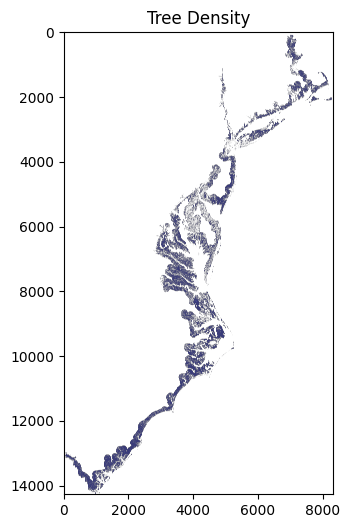

In [5]:
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(treedensity_2022, cmap='tab20b')
ax.set_title("Tree Density", fontsize=12)

In [7]:
hs_data = hs.read()
dtd_data = dtd.read()

hs_float = hs_data.astype(np.float32)
dtd_float = dtd_data.astype(np.float32)

hs = hs_float
dtd = dtd_float

In [29]:
#test
train_ds = tf.data.Dataset.from_tensors((X, y))
train_ds = train_ds.repeat()  # infinite stream of augmented whole images
train_ds = train_ds.map(lambda a,b: (tf.cast(a, tf.float32), tf.cast(b, tf.float32)))
train_ds = train_ds.map(lambda a,b: augment_tf(a,b), num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#val
val_ds = tf.data.Dataset.from_tensors((X, y)).repeat()
val_ds = val_ds.map(lambda a,b: (tf.cast(a, tf.float32), tf.cast(b, tf.float32)))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [30]:
target_h, target_w = model.input_shape[1], model.input_shape[2]
X_resized = tf.image.resize(X.astype('float32'), (target_h, target_w)).numpy()
print("Resized to:", X_resized.shape)

Resized to: (572, 572, 8332)


Shapes: X = (14271, 8332, 3)  Y = (14271, 8332)


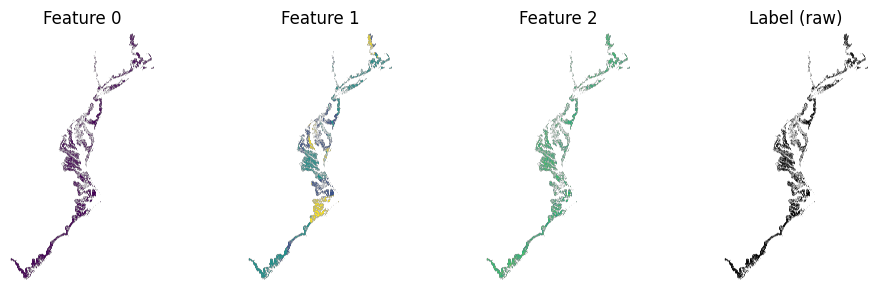

In [73]:
def load_and_stack(feature_paths, label_path, resampling=Resampling.nearest):
    with rasterio.open(label_path) as ref:
        ref_arr = ref.read(1).astype(np.float32)
        H, W = ref.height, ref.width
        ref_transform = ref.transform

    stacks = []
    for p in feature_paths:
        with rasterio.open(p) as src:
            if src.width == W and src.height == H and src.transform == ref_transform:
                arr = src.read(1).astype(np.float32)
            else:
                arr = src.read(
                    1,
                    out_shape=(H, W),
                    resampling=resampling
                ).astype(np.float32)
        stacks.append(arr)

    X = np.stack(stacks, axis=-1)
    Y = ref_arr
    return X, Y

X, Y = load_and_stack(paths, label_path)
print("Shapes: X =", X.shape, " Y =", Y.shape)

# Visualize
plt.figure(figsize=(10,3))
for i in range(X.shape[-1]):
    plt.subplot(1, X.shape[-1] + 1, i+1)
    plt.imshow(X[...,i], cmap='viridis'); plt.title(f"Feature {i}"); plt.axis('off')

plt.subplot(1, X.shape[-1]+1, X.shape[-1]+1)
plt.imshow(Y, cmap='gray'); plt.title("Label (raw)"); plt.axis('off')
plt.tight_layout(); plt.show()

In [74]:
def preprocess_label(Y):
    uniq = np.unique(Y)
    if set(uniq).issubset({0,1}):
        return Y.astype(np.uint8)

    thr = np.median(Y)
    print("Label not binary — thresholding at:", thr)
    return (Y > thr).astype(np.uint8)

Y_bin = preprocess_label(Y)
print("Label unique values:", np.unique(Y_bin))

PATCH_SIZE = 16
STRIDE = 16

def extract_patches(X, Y, patch_size=PATCH_SIZE, stride=STRIDE):
    H, W, C = X.shape
    X_patches, Y_patches = [], []

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            x_patch = X[y:y+patch_size, x:x+patch_size, :]
            y_patch = Y[y:y+patch_size, x:x+patch_size]

            if np.any(np.isnan(x_patch)):
                continue

            X_patches.append(x_patch)
            Y_patches.append(y_patch)

    return np.array(X_patches), np.array(Y_patches)

patches_X, patches_Y = extract_patches(X, Y_bin)
print("Extracted:", patches_X.shape, patches_Y.shape)


Label not binary — thresholding at: nan
Label unique values: [0]
Extracted: (1051, 16, 16, 3) (1051, 16, 16)


In [62]:
MAX_PATCHES = 50
if patches_X.shape[0] > MAX_PATCHES:
    idx = np.random.choice(patches_X.shape[0], MAX_PATCHES, replace=False)
    patches_X = patches_X[idx]; patches_Y = patches_Y[idx]

patches_X = patches_X.astype(np.float32)
patches_Y = patches_Y.astype(np.uint8)[..., np.newaxis]

X_train, X_tmp, Y_train, Y_tmp = train_test_split(
    patches_X, patches_Y, test_size=0.30, random_state=42
)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_tmp, Y_tmp, test_size=0.50, random_state=42
)

print("Split sizes:", len(X_train), len(X_val), len(X_test))

def make_dataset(X, Y, batch=8, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    ds = ds.map(lambda a,b: (tf.cast(a, tf.float32), tf.cast(b, tf.float32)))
    if shuffle: ds = ds.shuffle(200)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train, Y_train)
val_ds   = make_dataset(X_val, Y_val, shuffle=False)
test_ds  = make_dataset(X_test, Y_test, shuffle=False)


Split sizes: 35 7 8


In [63]:
def simple_unet(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPool2D()(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPool2D()(c2)

    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPool2D()(c3)

    # Bottleneck
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(p3)
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(b)

    # Decoder
    u3 = layers.UpSampling2D()(b)
    u3 = layers.Concatenate()([u3, c3])
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u3)
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.Concatenate()([u2, c2])
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(c5)

    u1 = layers.UpSampling2D()(c5)
    u1 = layers.Concatenate()([u1, c1])
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(c6)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)

    return models.Model(inputs, outputs)

model = simple_unet((PATCH_SIZE, PATCH_SIZE, X.shape[-1]))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 16, 16, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 16, 16,    │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 16, 16,    │      9,248 │ conv2d_31[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 8, 8, 32)  │          0 │ conv2d_32[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 8, 8, 64)  │     18,496 │ max_pooling2d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 8, 8, 64)  │     36,928 │ conv2d_33[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 4, 4, 64)  │          0 │ conv2d_34[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 4, 4, 128) │     73,856 │ max_pooling2d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 4, 4, 128) │    147,584 │ conv2d_35[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 2, 2, 128) │          0 │ conv2d_36[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 2, 2, 256) │    295,168 │ max_pooling2d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 2, 2, 256) │    590,080 │ conv2d_37[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_4     │ (None, 4, 4, 256) │          0 │ conv2d_38[0][0]   │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 4, 4, 384) │          0 │ up_sampling2d_4[… │
│ (Concatenate)       │                   │            │ conv2d_36[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 4, 4, 128) │    442,496 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 4, 4, 128) │    147,584 │ conv2d_39[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_5     │ (None, 8, 8, 128) │          0 │ conv2d_40[0][0]   │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 8, 8, 192) │          0 │ up_sampling2d_5[… │
│ (Concatenate)       │                   │            │ conv2d_34[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 8, 8, 64)  │    110,656 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 8, 8, 64)  │     36,928 │ conv2d_41[0][0] 

 Total params: 1,946,881 (7.43 MB)

 Trainable params: 1,946,881 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4123 - loss: 0.6575

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.7769 - loss: 0.3487 - val_accuracy: 1.0000 - val_loss: 1.8678e-15
Epoch 2/8
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 3.7124e-16

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 1.6292e-16 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/8
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/8
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/8
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


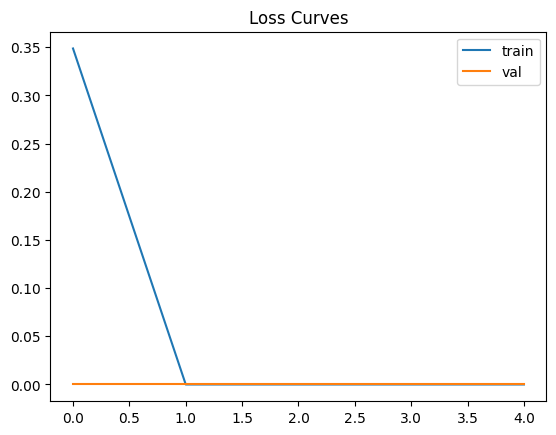

In [67]:
EPOCHS = 8

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(outputs, "best_model.h5"),
        save_best_only=True,
        monitor="val_loss"
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=3,
        restore_best_weights=True,
        monitor="val_loss"
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss Curves")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Pixel Accuracy: 1.0
Balanced Accuracy: 1.0
IoU: 0
Confusion Matrix:
 [[2048]]


2025-12-03 00:51:18.552229: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/opt/anaconda3/envs/tf/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/opt/anaconda3/envs/tf/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


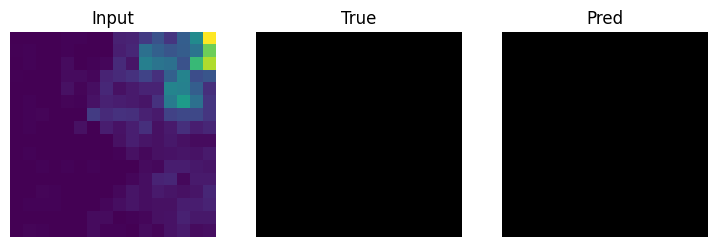

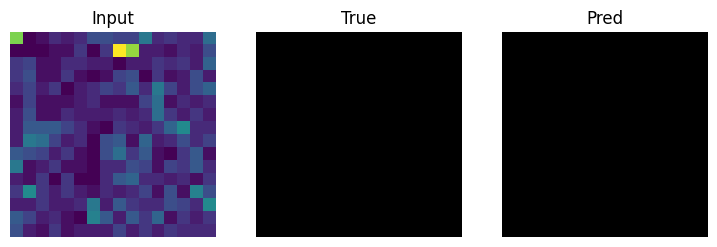

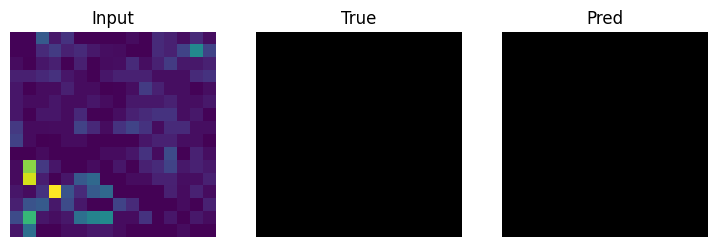

In [68]:
y_pred = model.predict(test_ds)
y_pred_bin = (y_pred > 0.5).astype(np.uint8)

Y_test_arr = np.concatenate([y for x,y in test_ds], axis=0)

y_true = Y_test_arr.flatten()
y_pred_f = y_pred_bin.flatten()

acc = accuracy_score(y_true, y_pred_f)
bal = balanced_accuracy_score(y_true, y_pred_f)
cm  = confusion_matrix(y_true, y_pred_f)

intersection = np.logical_and(y_true==1, y_pred_f==1).sum()
union = np.logical_or(y_true==1, y_pred_f==1).sum()
iou = intersection / union if union else 0

print("Pixel Accuracy:", acc)
print("Balanced Accuracy:", bal)
print("IoU:", iou)
print("Confusion Matrix:\n", cm)

# Show a few examples
for i in range(3):
    plt.figure(figsize=(9,3))
    plt.subplot(1,3,1); plt.imshow(X_test[i].sum(axis=2)); plt.title("Input"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(Y_test[i,...,0], cmap='gray'); plt.title("True"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(y_pred_bin[i,...,0], cmap='gray'); plt.title("Pred"); plt.axis('off')
    plt.show()


In [69]:
#improvments

Confusion matrix:
 [[2048    0]
 [   0    0]]


<Figure size 500x500 with 0 Axes>

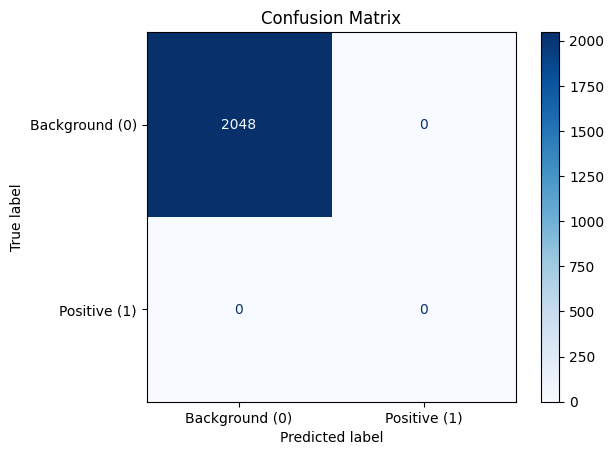

In [72]:

# Flatten predictions and true labels
y_true_flat = Y_test_arr.flatten()
y_pred_flat = y_pred_bin.flatten()

# Compute confusion matrix
cm = confusion_matrix(y_true_flat, y_pred_flat, labels=[0,1])
print("Confusion matrix:\n", cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Background (0)", "Positive (1)"])
plt.figure(figsize=(5,5))
disp.plot(values_format='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()